# qGAN Experiment Tutorial

Use this notebook to run or load one selected experiment, run or load a battery, and analyze completed checkpoints.


## 1. Setup

Run this notebook from inside the repository or from `qgan/notebooks`. The cell below makes `qgan/src` importable without installing the package.


In [13]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = None

for candidate in (cwd, *cwd.parents):
    if (candidate / "src" / "qgan_v2").is_dir() and (candidate / "configs").is_dir():
        qgan_dir = candidate
        break
    if (candidate / "qgan" / "src" / "qgan_v2").is_dir():
        qgan_dir = candidate / "qgan"
        break

if qgan_dir is None:
    raise RuntimeError("Could not find qgan project directory from current working directory.")

repo_root = qgan_dir.parent
src_path = qgan_dir / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("qgan_dir:", qgan_dir)
print("repo_root:", repo_root)


qgan_dir: /home/benat/Qiskit-IBM/qgan
repo_root: /home/benat/Qiskit-IBM


In [14]:
from qgan_v2.config.battery import create_battery_configs
from qgan_v2.config.loader import load_config_file, load_run_config
from qgan_v2.implementations.registry import IMPLEMENTATIONS
from qgan_v2.main import run_battery, run_train
from qgan_v2.storage.paths import get_run_path, get_training_data_filename, resolve_data_path
from qgan_v2.training.data import load_training_data_file
from qgan_v2.visualization import get_visual_config, run_visualization

state = None
battery_states = {}
battery_results = []
valid_config_files = []

sorted(IMPLEMENTATIONS)


['manual_estimator', 'qml_torch', 'runtime_packed']

## 2. IBM Runtime Credentials

This cell is optional. Enable it only when you need to save or verify IBM Runtime credentials.


In [15]:
save_account = False
check_runtime_account = False

if save_account or check_runtime_account:
    from getpass import getpass
    from qiskit_ibm_runtime import QiskitRuntimeService

if save_account:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=getpass("IBM Quantum API token: "),
        instance=None,
        set_as_default=True,
        overwrite=True,
        verify=True,
    )

if check_runtime_account:
    service = QiskitRuntimeService()
    print("Available backends:", len(service.backends()))


## 3. Single Experiment

The first YAML file in `configs/singles` is selected by default. Set `single_config_path` to choose another one.


In [16]:
single_config_path = repo_root / "qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/config.yaml"

single_config_files = sorted((qgan_dir / "configs" / "singles").glob("*.yaml"))
if single_config_path is None:
    if not single_config_files:
        raise FileNotFoundError("No single config files found in qgan/configs/singles.")
    single_config_path = single_config_files[0]

config_path = Path(single_config_path)
config = load_run_config(config_path)
training_data_file = get_training_data_filename(config)
state = None

print("single config:", config_path)
print("run id:", config["run"]["id"])
print("checkpoint:", training_data_file)
print("checkpoint_exists:", training_data_file.exists())


single config: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/config.yaml
run id: base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0
checkpoint: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/training_data.pth
checkpoint_exists: True


### Run Or Load

Choose one boolean. Function arguments stay in the function call.


In [17]:
run_single_experiment = False

if run_single_experiment:
    state = run_train(str(config_path), reset_data=False)
else:
    if not training_data_file.exists():
        raise FileNotFoundError(f"No checkpoint found: {training_data_file}")
    state = load_training_data_file(training_data_file)
    print("loaded state:", training_data_file)

loaded state: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/training_data.pth


### Inspect Checkpoint


In [18]:
print("current_epoch:", state.current_epoch)
print("best_eval:", state.metrics.best_eval())

current_epoch: 238
best_eval: 3.032940695344694


### Visualize


In [19]:
visualize_experiment_results = False

if training_data_file.exists() and visualize_experiment_results:
    run_visualization(
        config_path,
        get_visual_config({
            "draw_circuits": False,
            "draw_hardware_layout": True,
            "draw_probs": False,
            "draw_images": True,
            "draw_results": True,
        }),
    )


## 4. Battery Experiments

The first YAML file in `configs/batteries` is selected by default. Set `battery_path` to choose another one.


In [20]:
battery_path = repo_root / "qgan/configs/batteries/train/train_times_gpu.yaml"

battery_files = sorted((qgan_dir / "configs" / "batteries").glob("**/*.yaml"))
if battery_path is None:
    if not battery_files:
        raise FileNotFoundError("No battery config files found in qgan/configs/batteries.")
    battery_path = battery_files[0]

battery_path = Path(battery_path)
print("battery:", battery_path)


battery: /home/benat/Qiskit-IBM/qgan/configs/batteries/train/train_times_gpu.yaml


### Run Or Load

Set `run_battery_experiments = True` to run the battery. Leave it `False` to load existing checkpoints. In both cases, `battery_states` is loaded from checkpoint files.


In [21]:
run_battery_experiments = False

battery_states = {}
battery_results = []
valid_config_files = []
invalid_config_files = []
missing_checkpoints = []

if run_battery_experiments:
    battery_results = run_battery(
        battery_path,
        reset_data=False,
        reset_rb=False,
        stop_on_error=False,
        overwrite=False,
        keep_states=False,
    )
    config_files = [Path(result["config_file"]) for result in battery_results]
else:
    battery_data_path = resolve_data_path(load_config_file(battery_path)["default_config_values"]["run"]["data_path"])
    config_files = sorted(battery_data_path.glob("*/config.yaml"))

for path in config_files:
    try:
        cfg = load_run_config(path)
    except Exception as exc:
        invalid_config_files.append((path, exc))
        continue

    valid_config_files.append(path)
    checkpoint = get_training_data_filename(cfg)
    if checkpoint.exists():
        battery_states[cfg["run"]["id"]] = load_training_data_file(checkpoint)
    else:
        missing_checkpoints.append(checkpoint)

print("config files:", len(config_files))
print("valid config files:", len(valid_config_files))
print("invalid config files:", len(invalid_config_files))
print("loaded states:", len(battery_states))
print("missing checkpoints:", len(missing_checkpoints))


config files: 185
valid config files: 185
invalid config files: 0
loaded states: 146
missing checkpoints: 39


### Battery Summary


In [22]:
for path in valid_config_files[:20]:
    cfg = load_run_config(path)
    checkpoint = get_training_data_filename(cfg)
    run_id = cfg["run"]["id"]
    print(
        run_id,
        "done=" + str(checkpoint.exists()),
        "loaded=" + str(run_id in battery_states),
    )

remaining = len(valid_config_files) - 20
if remaining > 0:
    print("...", remaining, "more configs")


amp-qml_torch-q16-noiseless-PSR-aerCPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-PSR-aerCPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-PSR-aerGPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-PSR-aerGPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-REG-aerCPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-REG-aerCPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-REG-aerGPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-REG-aerGPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-SPSA-aerCPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-SPSA-aerCPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-SPSA-aerGPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noiseless-SPSA-aerGPU-rand1-seed0 done=False loaded=False
amp-qml_torch-q16-noisy-PSR-aerCPU-rand0-seed0 done=False loaded=False
amp-qml_torch-q16-noisy-P

## 5. Implementation Adapters

Quick view of implementations in the battery configs loaded above.


In [23]:
for path in valid_config_files[:20]:
    cfg = load_run_config(path)
    print(path.relative_to(qgan_dir))
    print("  implementation:", cfg["implementation"]["name"])
    print("  preset:", cfg["experiment"]["implementation"])
    print("  gradient:", cfg["experiment"]["gradient_method"])
    print()

remaining = len(valid_config_files) - 20
if remaining > 0:
    print("...", remaining, "more configs")


data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand0-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: PSR

data/train/times/amp-qml_torch-q16-noiseless-PSR-aerCPU-rand1-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: PSR

data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand0-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: PSR

data/train/times/amp-qml_torch-q16-noiseless-PSR-aerGPU-rand1-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: PSR

data/train/times/amp-qml_torch-q16-noiseless-REG-aerCPU-rand0-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: REG

data/train/times/amp-qml_torch-q16-noiseless-REG-aerCPU-rand1-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: REG

data/train/times/amp-qml_torch-q16-noiseless-REG-aerGPU-rand0-seed0/config.yaml
  implementation: qml_torch
  preset: amp
  gradient: REG

data/train/times/amp-qml_to

## 6. Thesis Results Analysis

This section loads completed experiment checkpoints and creates the thesis figures. Keep each plot filtered to one evaluation metric and one matched comparison.

In [24]:
import matplotlib.pyplot as plt

from qgan_v2.analysis import (
    DEFAULT_PAIR_FIELDS,
    filter_results,
    load_results,
    paired_metric_deltas,
    plot_convergence_comparison,
    plot_final_metric,
    plot_metric_by_category_field,
    plot_metric_by_numeric_field,
    plot_paired_delta,
    plot_quality_vs_time,
    plot_runtime,
    plot_seed_sensitivity,
    print_group_summary,
    representative_runs,
    results_table,
    truncate_results,
    unique_values,
)

conv_results = load_results(qgan_dir / "data" / "train")
timing_results = load_results(qgan_dir / "data" / "train" / "times")

print("convergence/case-study runs:", len(conv_results))
print("timing runs:", len(timing_results))
print("convergence presets:", unique_values(conv_results, "preset"))
print("convergence implementations:", unique_values(conv_results, "implementation"))
print("convergence execution types:", unique_values(conv_results, "execution_type"))
print("convergence gradients:", unique_values(conv_results, "gradient_method"))
print("convergence qubits:", unique_values(conv_results, "n_qubits"))
print("convergence randomness:", unique_values(conv_results, "randomness"))
print("timing presets:", unique_values(timing_results, "preset"))


convergence/case-study runs: 696
timing runs: 185
convergence presets: ['amp', 'ang', 'base']
convergence implementations: ['qml_torch', 'runtime_packed']
convergence execution types: ['noiseless', 'noisy', 'real']
convergence gradients: ['PSR', 'REG', 'SPSA']
convergence qubits: [16, 4, 8]
convergence randomness: [0, 0.1, 0.25, 0.5, 1]
timing presets: ['amp', 'ang', 'base']


### Comparable Groups

Groups fix the experimental configuration and vary only seed. Use this to check which comparisons have repeated runs.

In [25]:
print("Convergence groups with at least 2 runs")
print_group_summary(conv_results, min_runs=2)

print("Timing groups with at least 1 run")
print_group_summary(timing_results, min_runs=1)

Convergence groups with at least 2 runs
preset=amp, implementation=qml_torch, packing=separate, execution_type=noiseless, gradient_method=PSR, n_qubits=16, randomness=0, device_mode=GPU noiseless, run_device=GPU, simulator_device=GPU, eval_method=gradient
  seeds: [0, 1, 2]
  completed: 0 / 3
preset=amp, implementation=qml_torch, packing=separate, execution_type=noiseless, gradient_method=PSR, n_qubits=16, randomness=0.1, device_mode=GPU noiseless, run_device=GPU, simulator_device=GPU, eval_method=gradient
  seeds: [0, 1, 2]
  completed: 0 / 3
preset=amp, implementation=qml_torch, packing=separate, execution_type=noiseless, gradient_method=PSR, n_qubits=16, randomness=0.25, device_mode=GPU noiseless, run_device=GPU, simulator_device=GPU, eval_method=gradient
  seeds: [0, 1, 2]
  completed: 0 / 3
preset=amp, implementation=qml_torch, packing=separate, execution_type=noiseless, gradient_method=PSR, n_qubits=16, randomness=0.5, device_mode=GPU noiseless, run_device=GPU, simulator_device=G

### Plot Defaults

Edit these defaults to move the whole analysis to another preset, device, qubit count, or randomness level.

In [26]:
base_filters = {
    "preset": "ang",
    "implementation": "qml_torch",
    "n_qubits": 4,
    "run_device": "CPU",
    "simulator_device": "CPU",
}

gradient_filters = {
    **base_filters,
    "execution_type": "noiseless",
    "randomness": 0,
}

noise_filters = {
    **base_filters,
    "gradient_method": "SPSA",
    "randomness": 0,
}

randomness_filters = {
    **base_filters,
    "execution_type": "noiseless",
}

device_time_filters = {
    "preset": "ang",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
}

print("gradient comparison runs:", len(filter_results(conv_results, **gradient_filters)))
print("noise comparison runs:", len(filter_results(conv_results, **noise_filters)))
print("randomness comparison runs:", len(filter_results(conv_results, **randomness_filters)))
print("device timing runs:", len(filter_results(timing_results, **device_time_filters)))


gradient comparison runs: 9
noise comparison runs: 6
randomness comparison runs: 45
device timing runs: 6


### Data Coverage Audit


In [27]:
analysis_requirements = {
    "gradient learning dynamics": {**gradient_filters},
    "seed sensitivity": {**base_filters, "execution_type": "noiseless", "gradient_method": "SPSA", "randomness": 0},
    "randomness strength": {**base_filters, "execution_type": "noiseless"},
    "randomizer circuit type": {**base_filters, "execution_type": "noiseless", "gradient_method": "SPSA"},
    "paired noisy/noiseless": {**base_filters, "gradient_method": ["SPSA", "PSR"], "randomness": 0},
    "implementation comparison": {
        "preset": "ang",
        "execution_type": "noisy",
        "gradient_method": "SPSA",
        "n_qubits": 4,
        "randomness": 0,
        "run_device": "CPU",
        "simulator_device": "CPU",
    },
    "device timing": {**device_time_filters, "execution_type": ["noiseless", "noisy", "real"]},
    "packing comparison": {
        "preset": "base",
        "implementation": "runtime_packed",
        "execution_type": "real",
        "gradient_method": "SPSA",
        "n_qubits": 4,
        "randomness": 0,
        "run_device": "CPU",
        "simulator_device": "CPU",
    },
}

for name, filters in analysis_requirements.items():
    source = timing_results if name in {"device timing", "packing comparison"} else conv_results
    selected = filter_results(source, **filters)
    print(name)
    print("  runs:", len(selected))
    print("  seeds:", unique_values(selected, "seed"))
    print("  implementations:", unique_values(selected, "implementation"))
    print("  execution types:", unique_values(selected, "execution_type"))
    print("  device modes:", unique_values(selected, "device_mode"))
    print("  random circuits:", unique_values(selected, "random_circuit"))
    print("  randomness:", unique_values(selected, "randomness"))


gradient learning dynamics
  runs: 9
  seeds: [0, 1, 2]
  implementations: ['qml_torch']
  execution types: ['noiseless']
  device modes: ['CPU noiseless']
  random circuits: []
  randomness: [0]
seed sensitivity
  runs: 3
  seeds: [0, 1, 2]
  implementations: ['qml_torch']
  execution types: ['noiseless']
  device modes: ['CPU noiseless']
  random circuits: []
  randomness: [0]
randomness strength
  runs: 45
  seeds: [0, 1, 2]
  implementations: ['qml_torch']
  execution types: ['noiseless']
  device modes: ['CPU noiseless']
  random circuits: [1]
  randomness: [0, 0.1, 0.25, 0.5, 1]
randomizer circuit type
  runs: 15
  seeds: [0, 1, 2]
  implementations: ['qml_torch']
  execution types: ['noiseless']
  device modes: ['CPU noiseless']
  random circuits: [1]
  randomness: [0, 0.1, 0.25, 0.5, 1]
paired noisy/noiseless
  runs: 11
  seeds: [0, 1, 2]
  implementations: ['qml_torch']
  execution types: ['noiseless', 'noisy']
  device modes: ['CPU noiseless', 'CPU noisy']
  random circuits: 

### 1. Learning Dynamics

Evaluation score is the primary learning curve. Individual seed curves are faint; the thick line is the median with IQR shading.

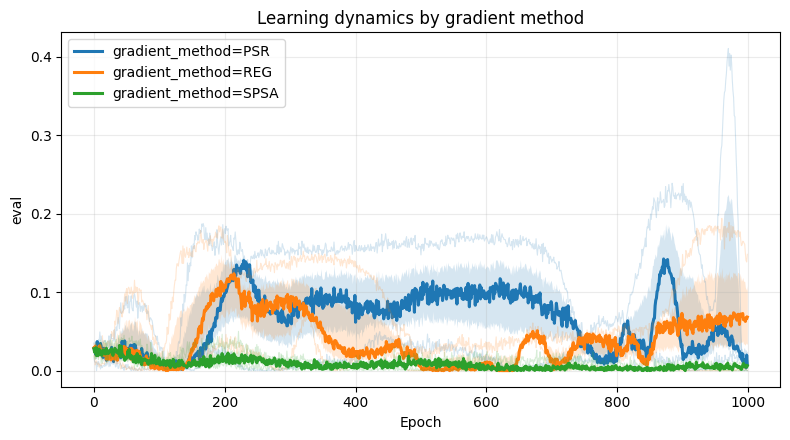

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_convergence_comparison(
    conv_results,
    compare_by="gradient_method",
    filters=gradient_filters,
    metric="eval",
    x_axis="epoch",
    center="median",
    spread="iqr",
    ax=ax,
)
ax.set_title("Learning dynamics by gradient method")
fig.tight_layout()

/home/benat/Qiskit-IBM/qgan/src/qgan_v2/analysis/results.py:483: RuntimeWarning: All-NaN slice encountered
  center_values = np.nanmedian(data, axis=0)
/home/benat/miniconda3/envs/qgan_v4/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


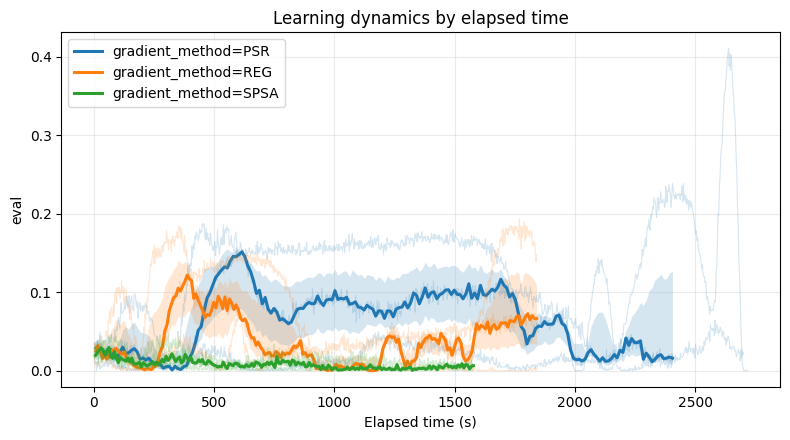

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_convergence_comparison(
    conv_results,
    compare_by="gradient_method",
    filters=gradient_filters,
    metric="eval",
    x_axis="elapsed",
    center="median",
    spread="iqr",
    ax=ax,
)
ax.set_title("Learning dynamics by elapsed time")
fig.tight_layout()

### 2. Best And Final-Window Results

Use these to compare independent seed runs. Do not treat epochs from one run as independent samples.

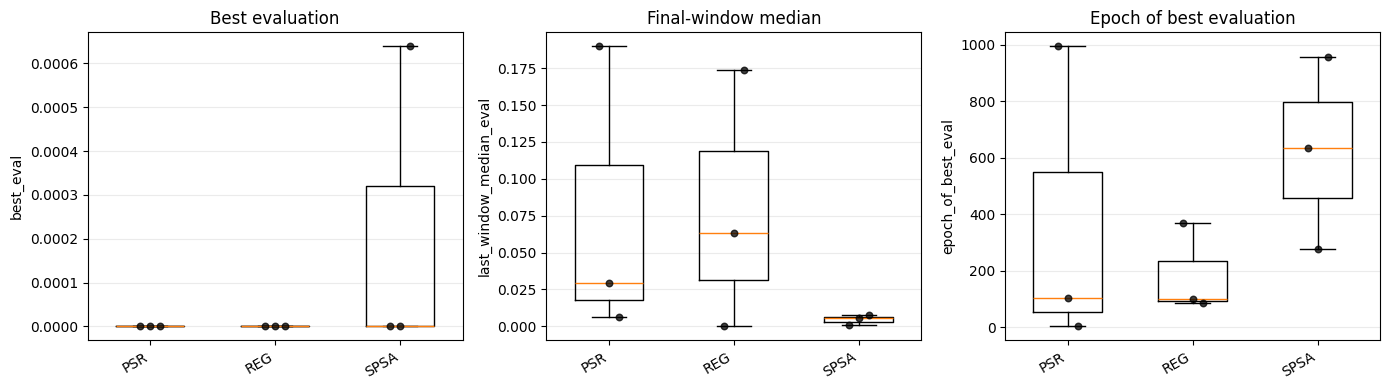

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_final_metric(
    conv_results,
    compare_by="gradient_method",
    metric_name="best_eval",
    filters=gradient_filters,
    ax=axes[0],
)
axes[0].set_title("Best evaluation")

plot_final_metric(
    conv_results,
    compare_by="gradient_method",
    metric_name="last_window_median_eval",
    filters=gradient_filters,
    ax=axes[1],
)
axes[1].set_title("Final-window median")

plot_final_metric(
    conv_results,
    compare_by="gradient_method",
    metric_name="epoch_of_best_eval",
    filters=gradient_filters,
    ax=axes[2],
)
axes[2].set_title("Epoch of best evaluation")

fig.tight_layout()

### 3. Quality-Cost Analysis

The first plot uses full convergence runs. The second uses short timing batteries for cleaner per-epoch timing.

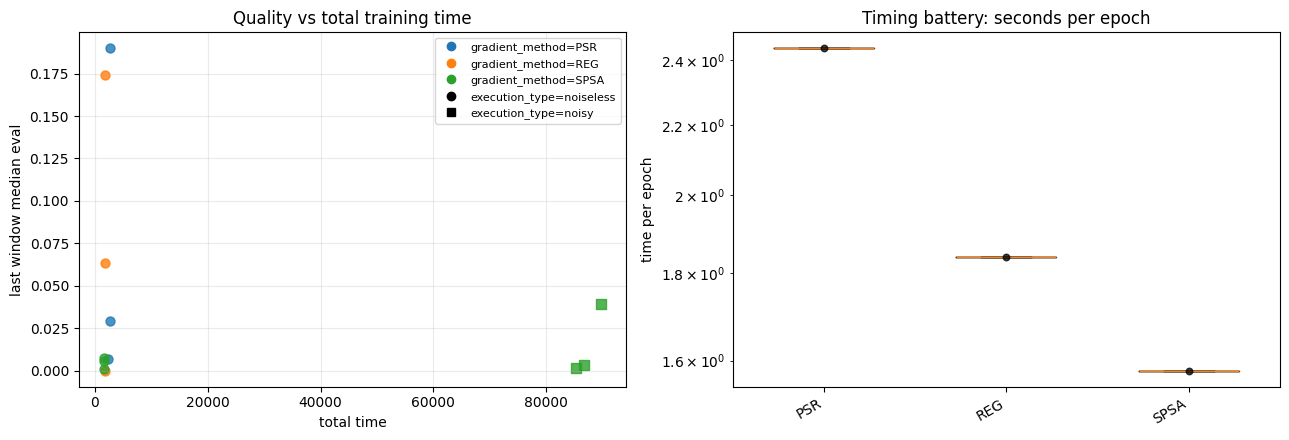

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_quality_vs_time(
    conv_results,
    color_by="gradient_method",
    marker_by="execution_type",
    quality_metric="last_window_median_eval",
    time_metric="total_time",
    filters={**base_filters, "randomness": 0},
    ax=axes[0],
)
axes[0].set_title("Quality vs total training time")

plot_runtime(
    timing_results,
    compare_by="gradient_method",
    metric_name="time_per_epoch",
    filters={**base_filters, "execution_type": "noiseless", "randomness": 0},
    log_scale=True,
    ax=axes[1],
)
axes[1].set_title("Timing battery: seconds per epoch")

fig.tight_layout()

### 4. Device-Time Comparison

Use timing runs for device cost, not as a direct replacement for quality analysis. The comparisons in this section are:

- CPU vs GPU simulator time with `implementation=qml_torch`, matched preset, gradient method, qubits, randomness, and execution type.
- Noiseless and noisy simulator timing shown separately, because density-matrix/noise-model execution changes the cost model.
- Gradient-method timing with `PSR`, `SPSA`, and `REG` under noiseless simulation; `REG` is not compared under noisy execution unless those runs exist.
- RH timing shown automatically when real-hardware timing results are present. Interpret RH as an execution-environment case study, because queue/runtime overhead and `runtime_packed` submission behavior are part of the measured cost.
- Presets are split in the next section so `base`, `ang`, and `amp` encodings are not collapsed into one timing statistic.


device modes: ['CPU noiseless', 'CPU noisy', 'GPU noiseless', 'GPU noisy', 'RH real']


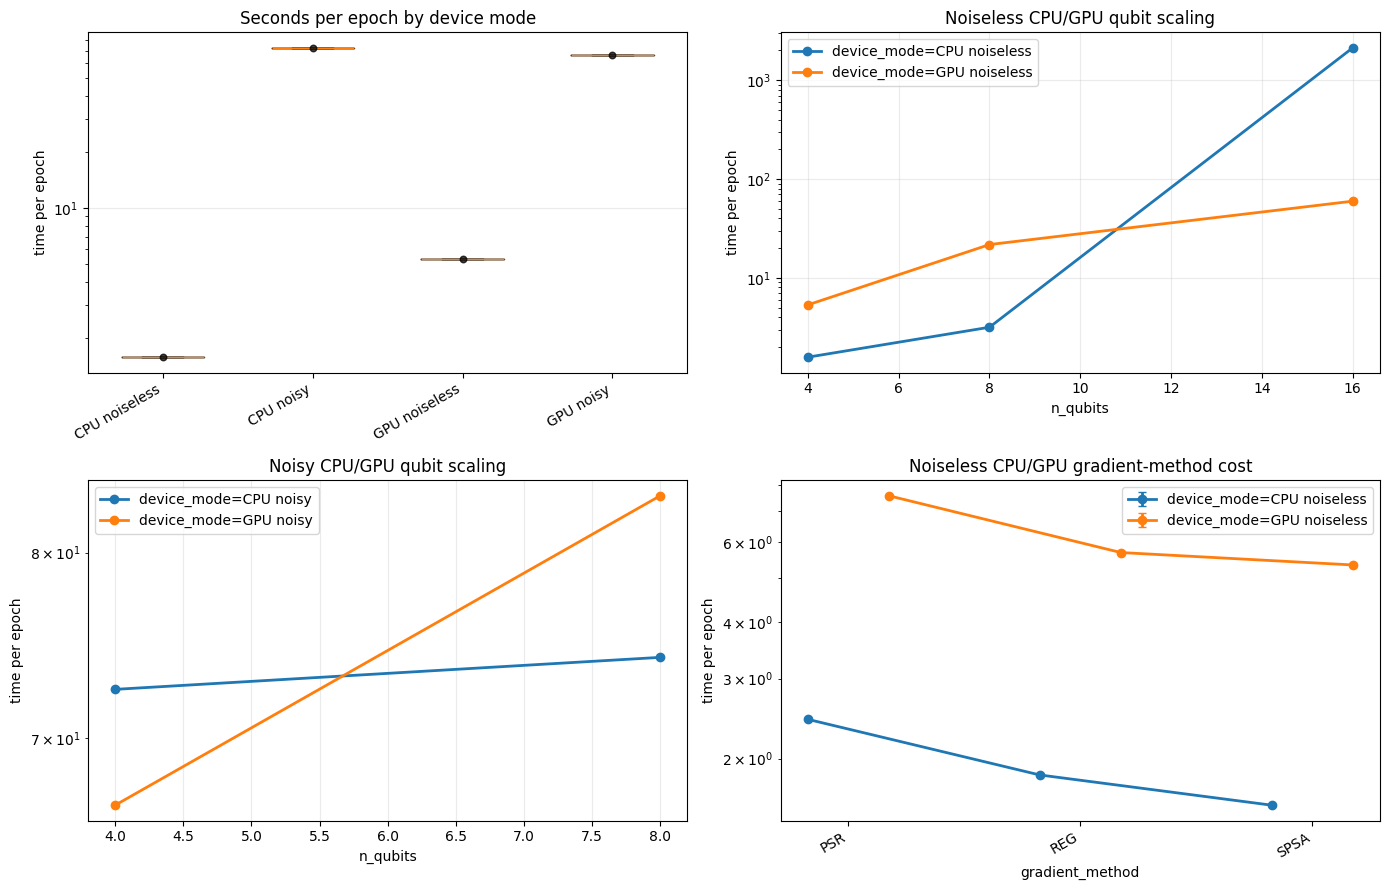

In [32]:
device_filters = {**device_time_filters, "execution_type": ["noiseless", "noisy", "real"]}
print("device modes:", unique_values(filter_results(timing_results, **device_filters), "device_mode"))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

plot_runtime(
    timing_results,
    compare_by="device_mode",
    metric_name="time_per_epoch",
    filters=device_filters,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_title("Seconds per epoch by device mode")

plot_metric_by_numeric_field(
    timing_results,
    x_field="n_qubits",
    metric_name="time_per_epoch",
    line_by="device_mode",
    filters={
        "preset": "ang",
        "implementation": "qml_torch",
        "execution_type": "noiseless",
        "gradient_method": "SPSA",
        "randomness": 0,
    },
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Noiseless CPU/GPU qubit scaling")

plot_metric_by_numeric_field(
    timing_results,
    x_field="n_qubits",
    metric_name="time_per_epoch",
    line_by="device_mode",
    filters={
        "preset": "ang",
        "implementation": "qml_torch",
        "execution_type": "noisy",
        "gradient_method": "SPSA",
        "randomness": 0,
    },
    ax=axes[2],
)
axes[2].set_yscale("log")
axes[2].set_title("Noisy CPU/GPU qubit scaling")

plot_metric_by_category_field(
    timing_results,
    x_field="gradient_method",
    metric_name="time_per_epoch",
    line_by="device_mode",
    filters={
        "preset": "ang",
        "implementation": "qml_torch",
        "execution_type": "noiseless",
        "n_qubits": 4,
        "randomness": 0,
    },
    ax=axes[3],
)
axes[3].set_yscale("log")
axes[3].set_title("Noiseless CPU/GPU gradient-method cost")

fig.tight_layout()


### 5. Device-Time By Preset

Compare `base`, `ang`, and `amp` separately. This avoids mixing different encodings while still showing whether a device mode is consistently faster or slower.


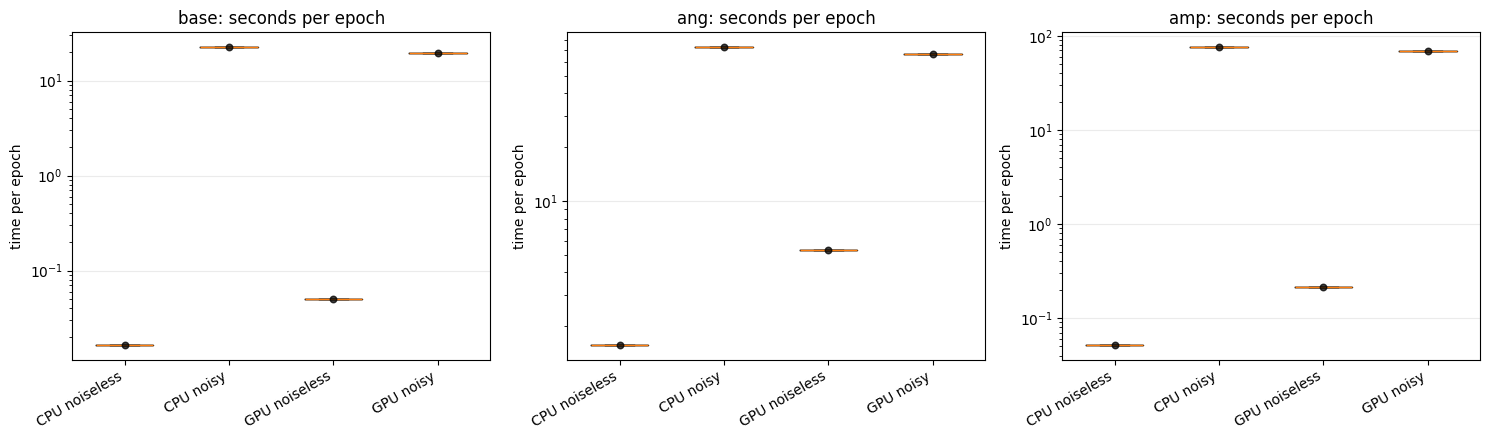

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for preset, ax in zip(["base", "ang", "amp"], axes):
    plot_runtime(
        timing_results,
        compare_by="device_mode",
        metric_name="time_per_epoch",
        filters={
            **device_time_filters,
            "preset": preset,
            "execution_type": ["noiseless", "noisy", "real"],
        },
        log_scale=True,
        ax=ax,
    )
    ax.set_title(f"{preset}: seconds per epoch")

fig.tight_layout()


### 6. Sensitivity To Training Seeds

This shows whether one seed systematically produces better or worse results under the selected matched setting.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_seed_sensitivity(
    conv_results,
    metric_name="last_window_median_eval",
    filters={**base_filters, "execution_type": "noiseless", "gradient_method": "SPSA", "randomness": 0},
    ax=ax,
)
ax.set_title("Seed sensitivity")
fig.tight_layout()

### 7. Random Input Ablation

This compares random input strength. Keep `random_circuit` fixed unless run IDs explicitly include it or labels distinguish the runs.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_metric_by_numeric_field(
    conv_results,
    x_field="randomness",
    metric_name="last_window_median_eval",
    line_by="gradient_method",
    filters={**base_filters, "execution_type": "noiseless"},
    center="median",
    spread="iqr",
    ax=axes[0],
)
axes[0].set_title("Random input strength ablation")

plot_metric_by_numeric_field(
    conv_results,
    x_field="random_circuit",
    metric_name="last_window_median_eval",
    line_by="randomness",
    filters={**base_filters, "execution_type": "noiseless", "gradient_method": "SPSA"},
    center="median",
    spread="iqr",
    ax=axes[1],
)
axes[1].set_title("Randomizer circuit ablation")

fig.tight_layout()


### 8. Qubit And Encoding Scaling

Analyze presets separately because `base`, `ang`, and `amp` do not necessarily use the same evaluation metric or task difficulty.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

plot_metric_by_numeric_field(
    conv_results,
    x_field="n_qubits",
    metric_name="last_window_median_eval",
    line_by="gradient_method",
    filters={
        "preset": "ang",
        "implementation": "qml_torch",
        "execution_type": "noiseless",
        "randomness": 0,
        "run_device": "CPU",
        "simulator_device": "CPU",
    },
    ax=axes[0],
)
axes[0].set_title("Quality scaling with qubits")

plot_metric_by_numeric_field(
    timing_results,
    x_field="n_qubits",
    metric_name="time_per_epoch",
    line_by="gradient_method",
    filters={
        "preset": "ang",
        "implementation": "qml_torch",
        "execution_type": "noiseless",
        "randomness": 0,
        "run_device": "CPU",
        "simulator_device": "CPU",
    },
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Cost scaling with qubits")

plot_metric_by_numeric_field(
    conv_results,
    x_field="n_qubits",
    metric_name="total_parameter_count",
    line_by="preset",
    filters={
        "implementation": "qml_torch",
        "execution_type": "noiseless",
        "gradient_method": "SPSA",
        "randomness": 0,
        "run_device": "CPU",
        "simulator_device": "CPU",
    },
    show_points=False,
    ax=axes[2],
)
axes[2].set_title("Trainable parameter scaling")

fig.tight_layout()

### 9. Paired Noisy-Versus-Noiseless Degradation

Pairs match seed, preset, implementation, gradient, qubits, randomness, devices, training budget, and evaluation method.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_paired_delta(
    conv_results,
    baseline_filters={**base_filters, "execution_type": "noiseless"},
    treatment_filters={**base_filters, "execution_type": "noisy"},
    metric_name="last_window_median_eval",
    x_field="gradient_method",
    value="delta",
    ax=ax,
)
ax.set_title("Noisy - noiseless evaluation degradation")
fig.tight_layout()

noise_deltas = paired_metric_deltas(
    conv_results,
    baseline_filters={**base_filters, "execution_type": "noiseless"},
    treatment_filters={**base_filters, "execution_type": "noisy"},
    metric_name="last_window_median_eval",
)
print("matched pairs:", len(noise_deltas))

### 10. Implementation Comparison

Use matched noisy simulation for implementation comparison. If no `runtime_packed` noisy runs exist yet, this cell will show only available data.


In [ ]:
implementation_filters = {
    "preset": "ang",
    "execution_type": "noisy",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "run_device": "CPU",
    "simulator_device": "CPU",
}

print("implementations:", unique_values(filter_results(conv_results, **implementation_filters), "implementation"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_convergence_comparison(
    conv_results,
    compare_by="implementation",
    filters=implementation_filters,
    metric="eval",
    x_axis="epoch",
    ax=axes[0],
)
axes[0].set_title("Learning dynamics by implementation")

plot_final_metric(
    conv_results,
    compare_by="implementation",
    metric_name="last_window_median_eval",
    filters=implementation_filters,
    ax=axes[1],
)
axes[1].set_title("Final-window quality by implementation")

fig.tight_layout()

### 11. Optional Packing Strategy Comparison

Only use this if joined packing is in scope. It is invalid for amplitude encoding and should not be mixed with the separate-only implementation analysis.


In [ ]:
packing_filters = {
    "preset": "base",
    "implementation": "runtime_packed",
    "execution_type": "real",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "run_device": "CPU",
    "simulator_device": "CPU",
}

print("packing values:", unique_values(filter_results(timing_results, **packing_filters), "packing"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_convergence_comparison(
    timing_results,
    compare_by="packing",
    filters=packing_filters,
    metric="eval",
    x_axis="epoch",
    ax=axes[0],
)
axes[0].set_title("Packing learning trace")

plot_runtime(
    timing_results,
    compare_by="packing",
    metric_name="time_per_epoch",
    filters=packing_filters,
    log_scale=True,
    ax=axes[1],
)
axes[1].set_title("Packing runtime per epoch")

plot_final_metric(
    timing_results,
    compare_by="packing",
    metric_name="approx_packed_width",
    filters=packing_filters,
    ax=axes[2],
)
axes[2].set_title("Approximate packed width")

fig.tight_layout()

### 12. Generated Output Examples

Select best, median, and worst runs by a fixed metric to avoid cherry-picking.


In [ ]:
representative_filters = {
    **base_filters,
    "execution_type": "noiseless",
    "gradient_method": "SPSA",
    "randomness": 0,
}
representative_source = filter_results(conv_results, **representative_filters)
representatives = representative_runs(representative_source, metric_name="last_window_median_eval")

for name, result in representatives.items():
    print(name, result.run_id, result.path / "config.yaml")

In [ ]:
representative_name = "median"

if representatives:
    representative_config = representatives[representative_name].path / "config.yaml"
    run_visualization(
        representative_config,
        get_visual_config({
            "draw_circuits": False,
            "draw_hardware_layout": False,
            "draw_probs": True,
            "draw_images": True,
            "draw_results": True,
        }),
    )

### 13. Real-Hardware 150-Epoch Case Study

Use real hardware as a case study. Compare against matched simulator traces truncated to the same epoch budget.


In [ ]:
hardware_max_epoch = 149
hardware_case_filters = {
    "preset": "base",
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "run_device": "CPU",
    "simulator_device": "CPU",
}

hardware_case = truncate_results(
    filter_results(
        conv_results,
        **{**hardware_case_filters, "execution_type": ["noiseless", "noisy", "real"]},
    ),
    max_epoch=hardware_max_epoch,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_convergence_comparison(
    hardware_case,
    compare_by="execution_type",
    filters={},
    metric="eval",
    x_axis="epoch",
    center="median",
    spread="iqr",
    ax=ax,
)
ax.set_title("Real-hardware case study, matched to 150 epochs")
fig.tight_layout()

hardware_rows = results_table(hardware_case)
for row in hardware_rows:
    print({
        "run_id": row["run_id"],
        "execution_type": row["execution_type"],
        "completed_epochs": row["completed_epochs"],
        "best_eval": row["best_eval"],
        "final_eval": row["final_eval"],
        "time_per_epoch": row["time_per_epoch"],
    })

### 14. Summary Tables

Rows are plain dictionaries so the notebook works without pandas. The optional dataframe cell is used when pandas is installed.


In [ ]:
summary_rows = results_table(filter_results(conv_results, **gradient_filters))

for row in summary_rows[:10]:
    print({
        "run_id": row["run_id"],
        "seed": row["seed"],
        "best_eval": row["best_eval"],
        "last_window_median_eval": row["last_window_median_eval"],
        "completed_epochs": row["completed_epochs"],
        "total_time": row["total_time"],
        "time_per_epoch": row["time_per_epoch"],
        "batch_size": row["batch_size"],
        "total_parameter_count": row.get("total_parameter_count"),
        "approx_packed_width": row.get("approx_packed_width"),
    })

In [ ]:
try:
    import pandas as pd

    display(pd.DataFrame(summary_rows).sort_values(["gradient_method", "seed"]))
except ImportError:
    print("pandas is not installed; use summary_rows directly.")